# Laboration 2 Maskininlärning 
## Förberedelser - Exploratary Data Analysis

### Importering av alla nödvändiga bibliotek:
- pandas: Dataframe hantering
- matplotlib: visualisering med diagram
- seaborn: avancerad visualisering och grafisk styling
- scipy.sparse: användning av glesa matriser
- sklearn.neighbors: använding av KNN-modellen

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns  

In [2]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

### Inläsning av dataset från CSV-filerna.

In [3]:
movies_df = pd.read_csv("movies.csv") 
ratings_df = pd.read_csv("ratings.csv") 
tags_df = pd.read_csv("tags.csv")

### Importering av python fil funktioner

In [4]:
from lab2 import movie_name, movie_recommendations

c:\Source\AI och Maskinlära 2024 YH\Machine-learning-AI24\.venv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


### Säkerställning att datan har laddats korrekt

In [5]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [7]:
tags_df.head()

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


### Anropar funktionen som ska returnera titel på filmen via dataframe och id

In [8]:
movie_name(movies_df, 19)

'Ace Ventura: When Nature Calls (1995)'

### Undersökning av vilka filmer som har fått högst ratings.
- Skapar top 10 variabel genom att implementera de 10 filmer som har fått mest betygsättning.

In [9]:
top10_most_rated = ratings_df["movieId"].value_counts()[:10]
top10_most_rated

movieId
318     122296
356     113581
296     108756
2571    107056
593     101802
260      97202
2959     86207
527      84232
480      83026
1196     80200
Name: count, dtype: int64

### 

In [10]:
# Tom listan ska spara filmtitlar
top10_most_rated_titles = []
for movie_id in top10_most_rated.index:
    top10_most_rated_titles.insert(0, movie_name(movies_df, movie_id))
    
# Ändrar visningstema via seaborn
sns.set_theme()

### Kontrollerar att top 10 filmer som är betygsatta har sparats med titel

In [11]:
top10_most_rated_titles

['Star Wars: Episode V - The Empire Strikes Back (1980)',
 'Jurassic Park (1993)',
 "Schindler's List (1993)",
 'Fight Club (1999)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Silence of the Lambs, The (1991)',
 'Matrix, The (1999)',
 'Pulp Fiction (1994)',
 'Forrest Gump (1994)',
 'Shawshank Redemption, The (1994)']

### Skapar ett barplot som visar hur många betygsättning är på top 10 filmerna.

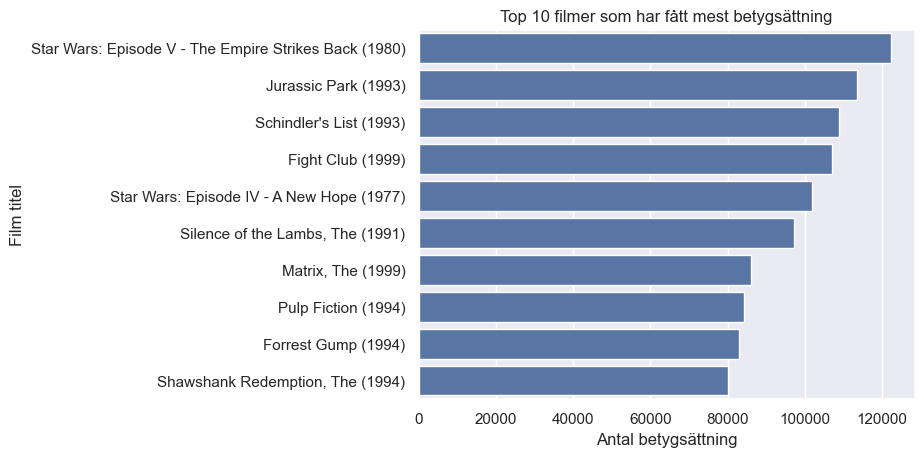

In [12]:
ax = sns.barplot(x=top10_most_rated, y=top10_most_rated_titles)
ax.set(xlabel="Antal betygsättning", ylabel="Film titel", title="Top 10 filmer som har fått mest betygsättning")
plt.show()

### Skapar medel på betygsättning poäng av de top 10 mest betygsatta filmer

In [13]:
top10_most_rated_mean = ratings_df[ratings_df["movieId"].isin(top10_most_rated.index)]["rating"].mean()
print(f"Medelvärde på top 10 betygsatta filmer: {top10_most_rated_mean:.1f} av 5")

Medelvärde på top 10 betygsatta filmer: 4.1 av 5


### Skapar ny kolumn i movies dataframe som heter "year" med endast årtal

In [14]:
movies_df["year"] = movies_df["title"].str[-5:-1]

# Kontrollerar att den funkar
movies_df.tail()

,movieId,title,genres,year
86532,288967,State of Siege: Temple Attack (2021),Action|Drama,2021
86533,288971,Ouija Japan (2021),Action|Horror,2021
86534,288975,The Men Who Made the Movies: Howard Hawks (1973),Documentary,1973
86535,288977,Skinford: Death Sentence (2023),Crime|Thriller,2023
86536,288983,UNZIPPED: An Autopsy of American Inequality (2...,Documentary,2021


### Skapar barplot som visar hur många filmer som släpptes under specifik år väljs top 10 filmer med mest utsläppning. 

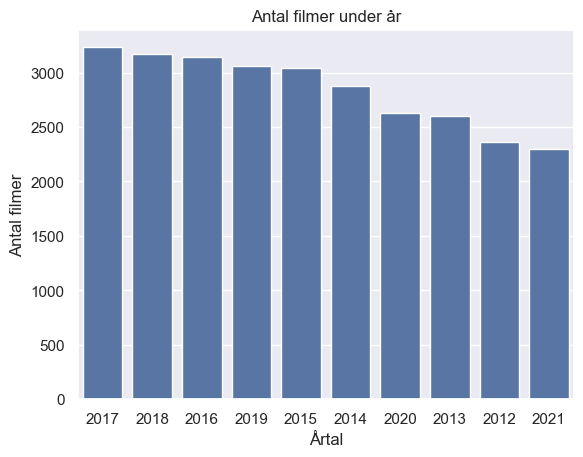

In [15]:
top10_movies_released_year = movies_df["year"].value_counts()[:10]

ax = sns.barplot(y = top10_movies_released_year, x = top10_movies_released_year.index)
ax.set(xlabel = "Årtal", ylabel = "Antal filmer", title = "Antal filmer under år")
plt.show()

## Utförande - Skapelse av sparse matrix

### Ser hur många rader ratings_df har

In [16]:
number_of_ratings = ratings_df.shape[0]
number_of_ratings

33832162

### Ser hur många olika filmer finns det i ratings_df

In [17]:
number_of_movies = ratings_df["movieId"].nunique()
number_of_movies

83239

In [18]:
print(f"Det finns totalt {number_of_ratings:,} betygsättningar för {number_of_movies:,} filmer".replace(",", " "))

Det finns totalt 33 832 162 betygsättningar för 83 239 filmer


### Uträkning av hur ofta varje movieID förekommer dess hur många betygsättning den har fått.

In [19]:
rating_counts = ratings_df["movieId"].value_counts()
rating_counts

movieId
318       122296
356       113581
296       108756
2571      107056
593       101802
           ...  
194901         1
212609         1
212613         1
212629         1
212631         1
Name: count, Length: 83239, dtype: int64

### Skapar en series med filmer som har mindre än 10000 betygsättning samt series och dataframe med 10000 eller mer betygsättning

In [20]:
less_than_10000_ratings = rating_counts[rating_counts < 10000]
movies10000_or_more_ratings = rating_counts[rating_counts >= 10000]
movies_10000_or_more_ratings = ratings_df[ratings_df["movieId"].isin(movies10000_or_more_ratings.index)]

In [21]:
less_than_10000_ratings

movieId
1321      9996
2087      9993
72226     9990
1272      9974
116823    9958
          ... 
194901       1
212609       1
212613       1
212629       1
212631       1
Name: count, Length: 82399, dtype: int64

In [22]:
movies10000_or_more_ratings

movieId
318      122296
356      113581
296      108756
2571     107056
593      101802
          ...  
3072      10035
1513      10027
7090      10024
1042      10023
55765     10008
Name: count, Length: 840, dtype: int64

In [23]:
movies_10000_or_more_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119
...,...,...,...,...
33832144,330975,6711,2.5,1091583650
33832149,330975,6874,4.0,1091684274
33832155,330975,7153,4.0,1091582733
33832159,330975,8622,4.0,1091581777


In [24]:
less_than_10000_ratings.sum()

np.int64(15148089)

In [25]:
print(f"Procent av borträknad data efter filteringen: {less_than_10000_ratings.sum() / number_of_ratings * 100:.1f}%")

Procent av borträknad data efter filteringen: 44.8%


In [26]:
print(f"Procent av data kvar efter filteringen: {len(movies_10000_or_more_ratings) / number_of_ratings * 100:.1f}%")

Procent av data kvar efter filteringen: 55.2%


In [27]:
print(f"Procent of fimer med mindre än 10000 betygsättningar {len(less_than_10000_ratings)/number_of_movies * 100:.1f}%")

Procent of fimer med mindre än 10000 betygsättningar 99.0%


### Det finns 82 399 filmer som har under 10 000 betygsättningar med totalt 15 148 089 betygsättningar. Det motsvarar 99% av filmer dock endast 44.8% av datasetet som ska inte inkluderas.
- Utan de det kommer finnas fortfarande 55.2% av data kvar vilket innebär alltså 18 684 073 betygsättningar kvar.

### Nu med 55.2% av data med ca 1% av top filmer så är det dags att skapa sparse matrix 
- Då var det dags att pivotera datan så att varje film blir en rad och varje användaren blir kolumn samt värde ska bli användarens betyg om det saknar värde då ska det fyllas med 0.
- Anledning är det blir bara 1 procent av filmer eftersom de flesta människor är upptagna med saker i livet och har endast tid för top filmer att slappna av. Time is a valuable thing.

In [28]:
movie_users_request = movies_10000_or_more_ratings.pivot(index="movieId", columns="userId", values="rating").fillna(0)


- Skapar en sparse matrix av pivot tabellen för att kunna spara minne och effektivisera KNN-beräkningar

In [29]:
movie_users_request_matrix = csr_matrix(movie_users_request.values)
movie_users_request_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18684073 stored elements and shape (840, 323357)>

### Skapelse av rekommendationssystem med KNN
- Dags att skapa en filtrerad lista med de filmer som ska finnas kvar efter urvalsporcessen.

In [30]:
movies_in_recommendations = movies_df[movies_df["movieId"].isin(movies_10000_or_more_ratings["movieId"].unique())].reset_index()
movies_in_recommendations

,index,movieId,title,genres,year
0,0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,5,Father of the Bride Part II (1995),Comedy,1995
4,5,6,Heat (1995),Action|Crime|Thriller,1995
...,...,...,...,...,...
835,54254,187593,Deadpool 2 (2018),Action|Comedy|Sci-Fi,2018
836,57778,195159,Spider-Man: Into the Spider-Verse (2018),Action|Adventure|Animation|Sci-Fi,2018
837,61176,202439,Parasite (2019),Comedy|Drama,2019
838,62208,204698,Joker (2019),Crime|Drama|Thriller,2019


### Tränar KNN-modell på glesa matrisen
- n-neighbors ska sättas till 20 för att hämta de 20 närmaste grannarna
- metric ska vara cosine för att cosinus likhet alltså för att fånga likheterna i betygsmönster
- algoritm ska vara brute för att se till att man hittar rätt filmer genom att jämföra allt med allt

In [31]:
model_KNN = NearestNeighbors(n_neighbors = 20, metric = "cosine", algorithm = "brute")
model_KNN.fit(movie_users_request_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=20)

### Anropar funktionen som ska be användare att skriva in filmtitel och få ut 5 matchande titlar alltså rekommendationer

In [32]:
movie_recommendations(movies_in_recommendations, tags_df, movies_df, model_KNN, movie_users_request_matrix)

Hittade via tag: 'wolverine'
Valde filmen baserat på taggen: X-Men: The Last Stand (2006)
Top 5 rekommendationer för: X-Men: The Last Stand (2006)
X2: X-Men United (2003)
X-Men Origins: Wolverine (2009)
X-Men: First Class (2011)
X-Men (2000)
Transformers (2007)


Rekommendationssystem använder sig av K-Nearist Neighbors så att den kan hitta de filmer som ligger närmast baserat på användernas betygssätningsmönster. Denna är baserad på Collaborative filtering som innebär att det baserar sig på användarnas samlade betyg historik om flera användare sätter likt betyg på likt filmer man kan anta att de har samma intresse. När liknande algorithm används i verkligheten. Det funkar för användare som har historiskt satt många betyg eller samt använder sig av taggen oftast använda för dessa filmer med jätte många antal betygsättningar dock funkar inte för de som har inte satt många betyg och är nya användare.

Content based methods är baserad på innehållets egeneskaper för att kunna ge ut rekommendationer. De tittar på detaljer som genre, skådespelare och teman. Det innebär att systemet lär sig vad du gillar utifrån dina val och interaktioner därför dessa rekommendationerna blir personligt anpassade efter specifikt personens preferenser till och med nya användare kan få hyfsat bra förslag baserat på infomration som ålder eller kön.

In [33]:
"""
References
1. python-programming-APTI-DZHAMURZAEV (2025, april 11). Github. Retrieved from: https://github.com/AptiDz/python-programming-APTI-DZHAMURZAEV
2. Linjär algebra AI24 GBG (2025, april 11). ITHS distans. Retrieve from: https://www.ithsdistans.se/course/view.php?id=1585
3. data-behandling-APTI-DZHAMURZAEV (2025, april 12). Github. Retrieved from: https://github.com/AptiDz/data-behandling-APTI-DZHAMURZAEV
4. statistiska_metoder (2025, april 12). Github. Retrieved from: https://github.com/AptiDz/statistiska_metoder
5. Machine-learning-AI24 (2025, april 12). Github. Retrieved from: https://github.com/AptiDz/Machine-learning-AI24
6. Complete A.I. & Machine Learning, Data Science Bootcamp (2025, april 12). (Andrei Neagoie, Daniel Bourke). Udemy. Retrieved from: https://www.udemy.com/course/complete-machine-learning-and-data-science-zero-to-mastery/
7. pandas.Series.str.slice. (2025, april 13). Pandas.pydata. Retrieved from: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.slice.html
8. How to filter Pandas dataframe using 'in' and 'not in' like in SQL (2025, april 13). Stackoverflow. Retrieved from: https://stackoverflow.com/questions/19960077/how-to-filter-pandas-dataframe-using-in-and-not-in-like-in-sql
9. What´s the difference between idxmax() and max() inside a groupby pandas (2025, april 13). Stackoverflow. Retrieved from: https://stackoverflow.com/questions/60083433/what%C2%B4s-the-difference-between-idxmax-and-max-inside-a-groupby-pandas
10. Setting a Threshold for FuzzyWuzzy's process.extratOne to avoid False Matches (2025, april 14). (vlogize). Youtube. Retrieve from: https://www.youtube.com/watch?v=XYTTC-_mkLU
11. What is collaborative filtering (2025, april 16). (Jacob Murel). IBM. Retrieved from: https://www.ibm.com/think/topics/collaborative-filtering
12. What is content based filtering (2025, april 16). (Jacob Murel). IBM. Retrieved from: https://www.ibm.com/think/topics/collaborative-filtering
"""


"\nReferences\n1. python-programming-APTI-DZHAMURZAEV (2025, april 11). Github. Retrieved from: https://github.com/AptiDz/python-programming-APTI-DZHAMURZAEV\n2. Linjär algebra AI24 GBG (2025, april 11). ITHS distans. Retrieve from: https://www.ithsdistans.se/course/view.php?id=1585\n3. data-behandling-APTI-DZHAMURZAEV (2025, april 12). Github. Retrieved from: https://github.com/AptiDz/data-behandling-APTI-DZHAMURZAEV\n4. statistiska_metoder (2025, april 12). Github. Retrieved from: https://github.com/AptiDz/statistiska_metoder\n5. Machine-learning-AI24 (2025, april 12). Github. Retrieved from: https://github.com/AptiDz/Machine-learning-AI24\n6. Complete A.I. & Machine Learning, Data Science Bootcamp (2025, april 12). (Andrei Neagoie, Daniel Bourke). Udemy. Retrieved from: https://www.udemy.com/course/complete-machine-learning-and-data-science-zero-to-mastery/\n7. pandas.Series.str.slice. (2025, april 13). Pandas.pydata. Retrieved from: https://pandas.pydata.org/docs/reference/api/pand